In [8]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [9]:
DATA_FILE = r"C:\Users\ASUS\OneDrive\Documents\Jan_315\ML_Deployment\Data\Telco_Customer (1).csv"
MODEL_FILE = 'churn_model.pkl'

In [10]:
df = pd.read_csv(DATA_FILE)

In [11]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [12]:
df.shape

(667, 20)

In [13]:
print('Columns',df.columns.tolist())

Columns ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


In [14]:
df.dtypes

State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

In [15]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,8.407796,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,13.994480,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,0.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,0.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,0.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,20.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,51.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


In [16]:
display(df.describe(include = 'all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,667,51,AZ,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account length,667.0,NaN,NaN,NaN,102.841079,40.81948,1.0,76.0,102.0,128.0,232.0
Area code,667.0,NaN,NaN,NaN,436.157421,41.783305,408.0,408.0,415.0,415.0,510.0
International plan,667,2,No,614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Voice mail plan,667,2,No,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number vmail messages,667.0,NaN,NaN,NaN,8.407796,13.99448,0.0,0.0,0.0,20.0,51.0
Total day minutes,667.0,NaN,NaN,NaN,180.948126,55.508628,25.9,146.25,178.3,220.7,334.3
Total day calls,667.0,NaN,NaN,NaN,100.937031,20.39679,30.0,87.5,101.0,115.0,165.0
Total day charge,667.0,NaN,NaN,NaN,30.761769,9.436463,4.4,24.86,30.31,37.52,56.83
Total eve minutes,667.0,NaN,NaN,NaN,203.355322,49.719268,48.1,171.05,203.7,236.45,361.8


In [17]:
# Clean column names
df.columns = df.columns.str.strip()

In [18]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


Series([], dtype: int64)

In [19]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [20]:
# Remove rows where target is missing
df = df.dropna(subset=["Churn"]).copy()

In [21]:
# IMPORTANT FIX:
# Convert Churn to a clean binary integer target.
# Handles False/True, 0/1, Yes/No, and string versions safely.
def convert_churn(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    text = str(value).strip().lower()
    if text in {"yes", "true", "1", "churn", "churned"}:
        return 1
    if text in {"no", "false", "0", "not churn", "not_churn"}:
        return 0
    try:
        number = float(text)
        if number in (0, 1):
            return int(number)
    except ValueError:
        pass
    return np.nan

In [22]:
df["Churn"] = df["Churn"].apply(convert_churn)
df = df.dropna(subset=["Churn"]).copy()
df["Churn"] = df["Churn"].astype(int)

In [23]:
print("Churn dtype:", df["Churn"].dtype)
print("Churn values:", sorted(df["Churn"].unique()))
print(df["Churn"].value_counts())

Churn dtype: int64
Churn values: [np.int64(0), np.int64(1)]
Churn
0    572
1     95
Name: count, dtype: int64


In [24]:
df.dtypes

State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                       int64
dtype: object

In [25]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [26]:
# Unique values in categorical columns
for col in df.select_dtypes(include="object").columns:
    print(f"\\n{col}:")
    print(f"---------------------------------------")
    print(df[col].value_counts(dropna=False).head(15))
    print(f"=======================================")

\nState:
---------------------------------------
State
AZ    19
WA    18
NM    18
KS    18
NJ    18
WV    18
ND    18
IN    17
ID    17
WI    17
TX    17
MS    17
RI    17
LA    16
VT    16
Name: count, dtype: int64
\nInternational plan:
---------------------------------------
International plan
No     614
Yes     53
Name: count, dtype: int64
\nVoice mail plan:
---------------------------------------
Voice mail plan
No     478
Yes    189
Name: count, dtype: int64


In [27]:
# Convert TotalCharges to numeric where applicable
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [28]:
# Strip whitespace from string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

In [29]:
# Remove customer ID because it is an identifier, not a predictive feature
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

In [30]:
# Show updated missing values
display(df.isna().sum().sort_values(ascending=False).head(10))


State                    0
Account length           0
Area code                0
International plan       0
Voice mail plan          0
Number vmail messages    0
Total day minutes        0
Total day calls          0
Total day charge         0
Total eve minutes        0
dtype: int64

In [31]:
df['Churn']

0      0
1      1
2      1
3      0
4      0
      ..
662    0
663    0
664    0
665    0
666    0
Name: Churn, Length: 667, dtype: int64

## 3.Exploratory data analysis (EDA)

In [32]:
#Target Distribution
if 'churn' in df.columns:
    churn_counts = df['Churn'].value_counts()
    churn_pct = df['churn'].value_counts(normalize=True).mul(100).round(2)

    fig, ax = plt.subplots(figsize=(7, 9))

    bars = churn_counts.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'])

    #Add number + percentage labels
    labels = [
        f"{count}\n({pct}%)" 
        for count, pct in zip(churn_counts, churn_pct)
    ]

    ax.bar_label(bars.containers[0], labels=labels, label_type='edge', fontsize=12)

    ax.set_title('Customer Churn Distribution')
    ax.xlabel('Churn')
    ax.ylabel('Number of Customers')
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

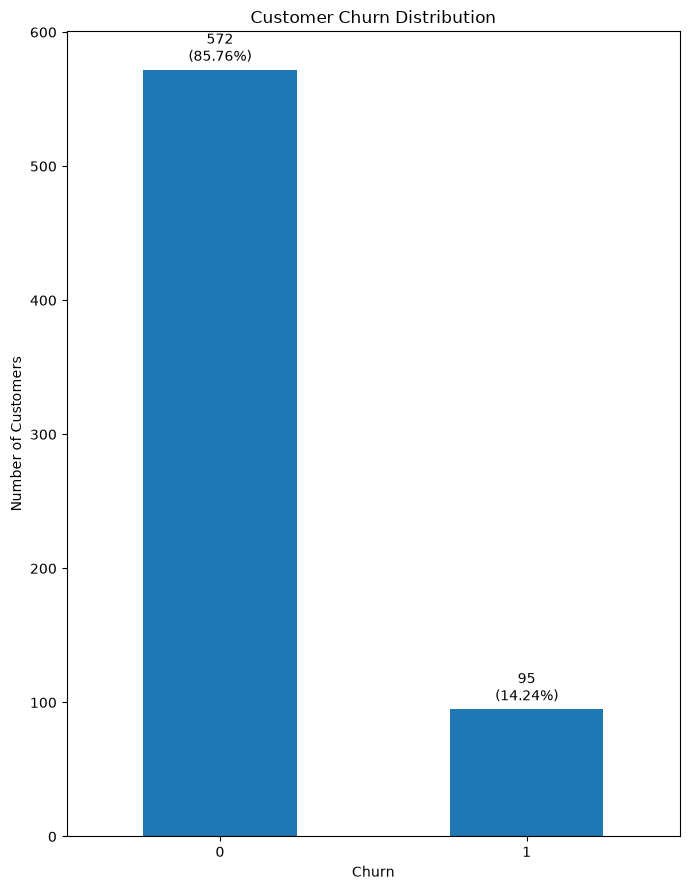

In [33]:
# Target distribution

if 'Churn' in df.columns:
    churn_counts = df['Churn'].value_counts()
    churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2)
    
    fig,ax = plt.subplots(figsize=(7,9))
    
    bars = churn_counts.plot(kind='bar',ax=ax)
    
    # Add Number + Percentage  labels
    labels = [
        f"{count}\n({pct}%)"
        for count,pct in zip(churn_counts,churn_pct)
    ]
    
    ax.bar_label(bars.containers[0],labels=labels,padding=3)
    
    ax.set_title('Customer Churn Distribution')
    ax.set_xlabel('Churn')
    ax.set_ylabel('Number of Customers')
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

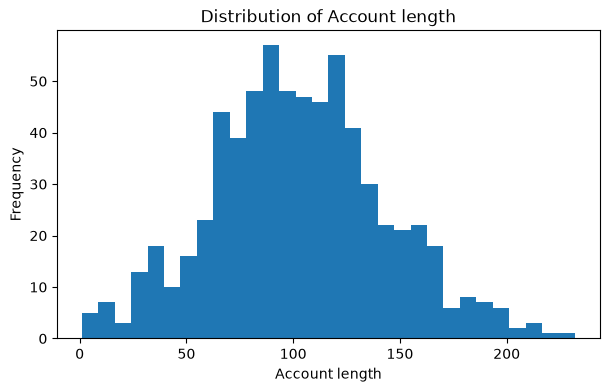

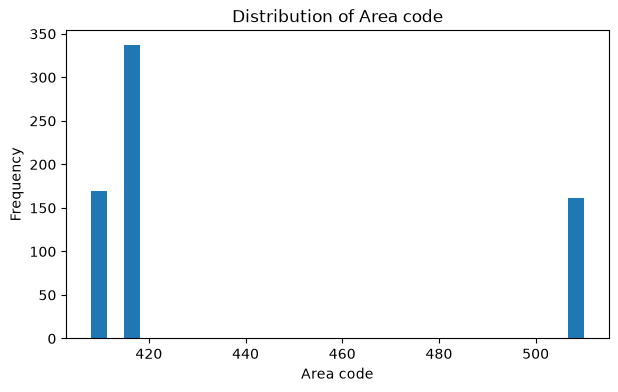

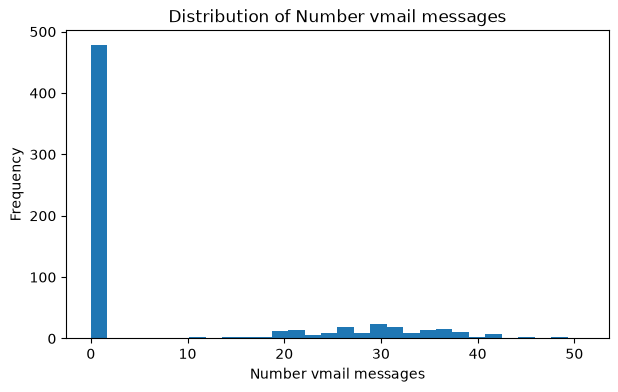

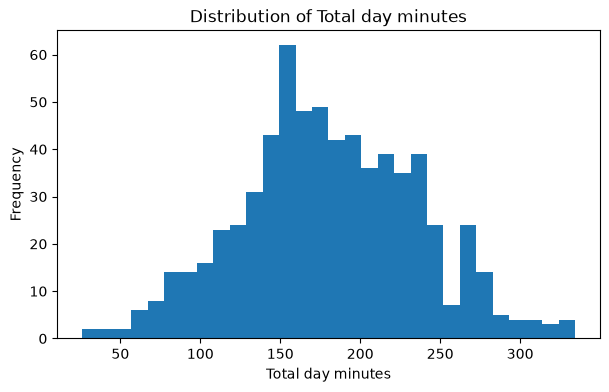

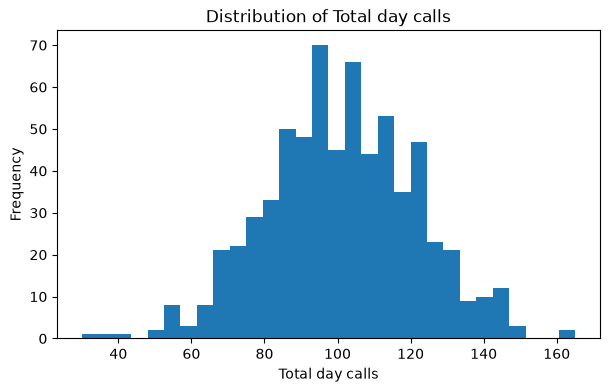

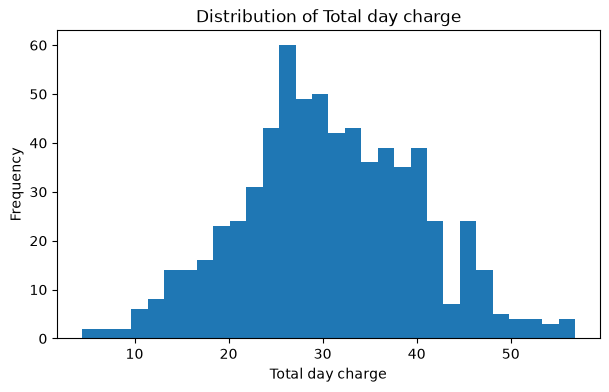

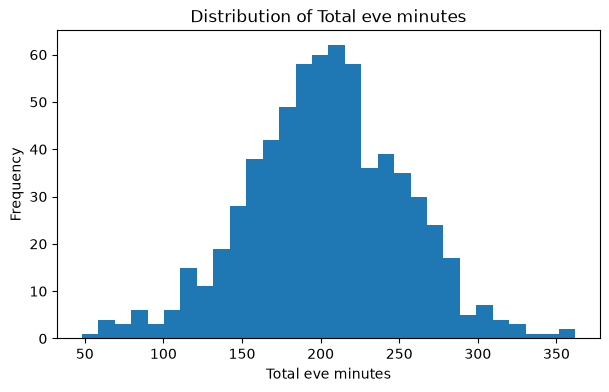

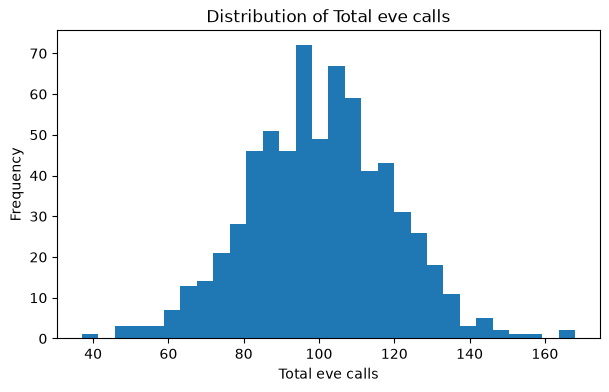

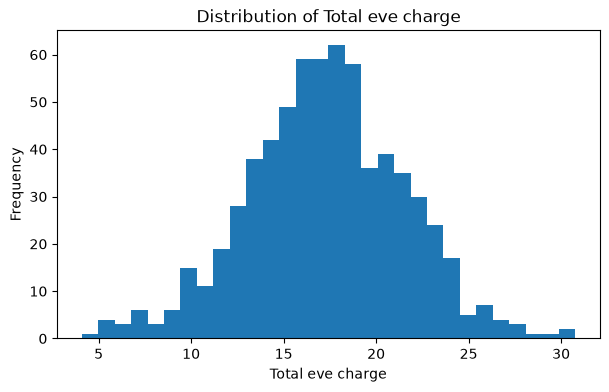

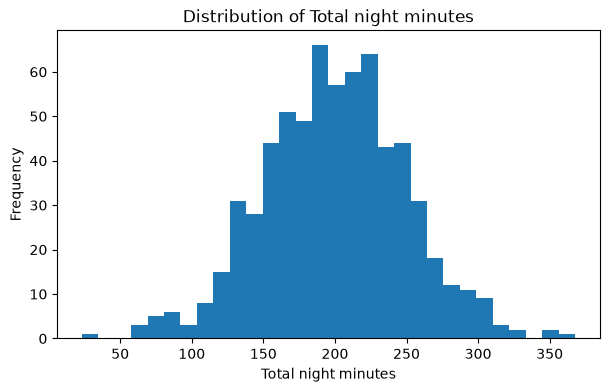

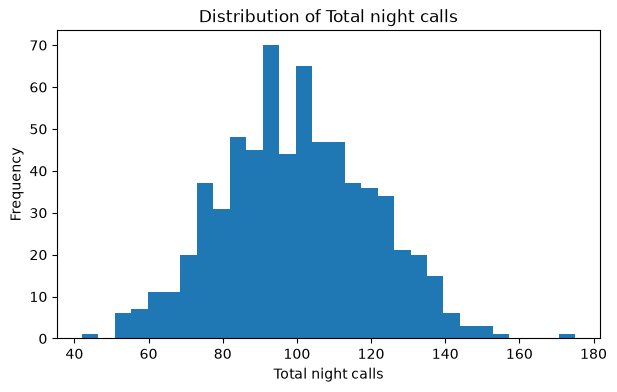

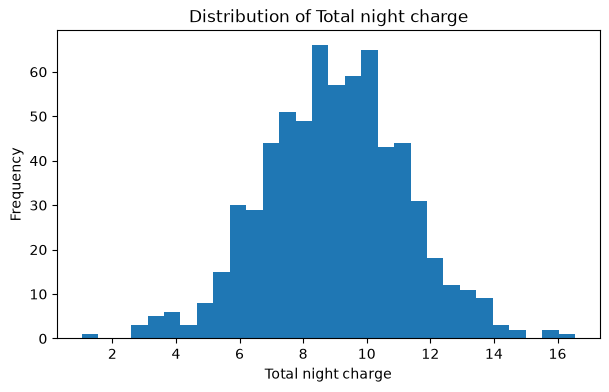

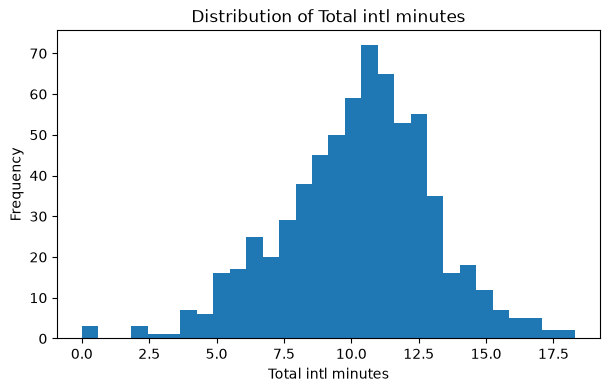

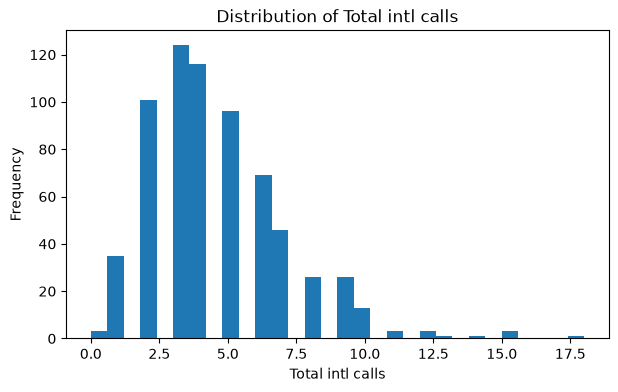

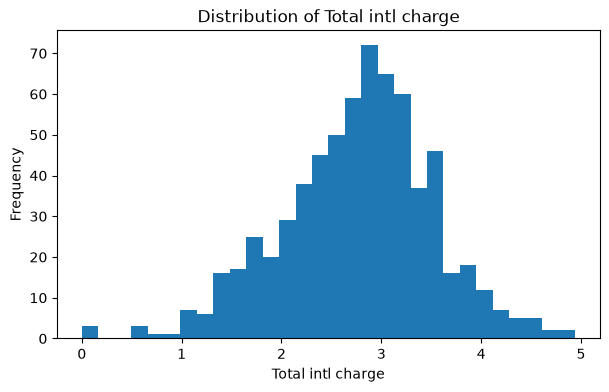

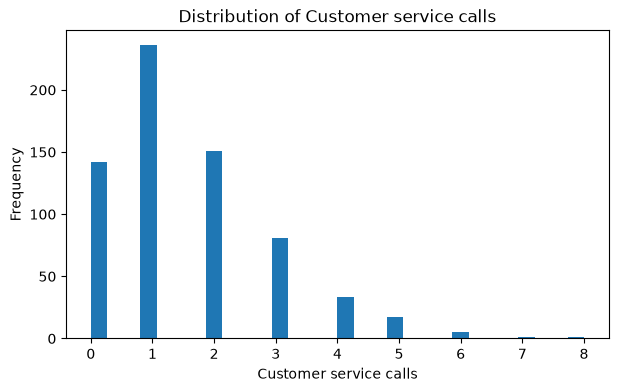

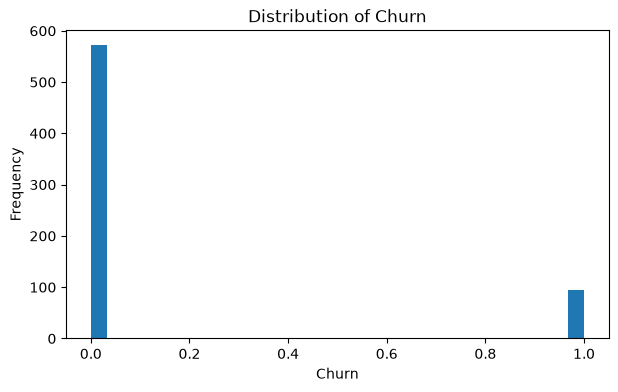

In [34]:
# Numerical feature distributions

num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(),bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [35]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='str')

In [36]:
candidate_cols = pd.Categorical(df)
candidate_cols

['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', ..., 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']
Length: 20
Categories (20, str): ['Account length', 'Area code', 'Churn', 'Customer service calls', ..., 'Total night calls', 'Total night charge', 'Total night minutes', 'Voice mail plan']

<Figure size 800x400 with 0 Axes>

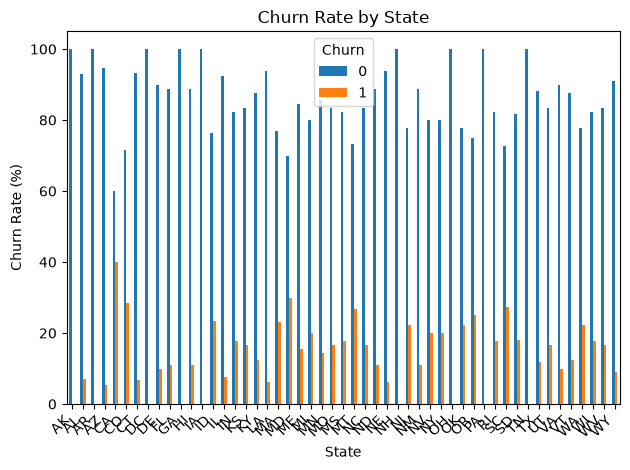

<Figure size 800x400 with 0 Axes>

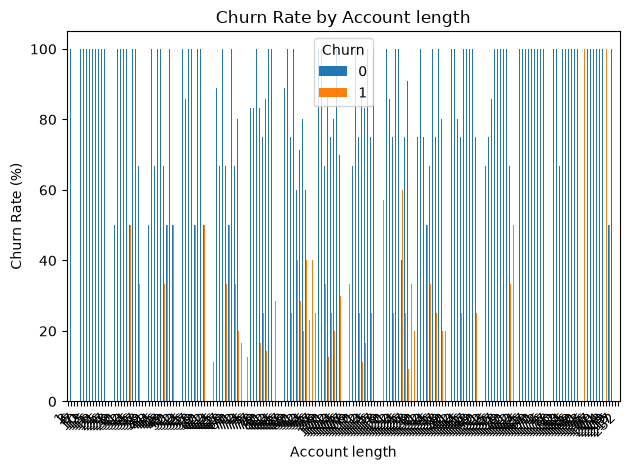

<Figure size 800x400 with 0 Axes>

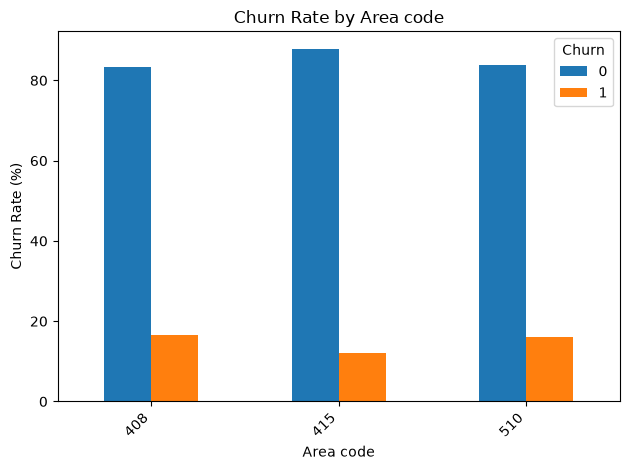

<Figure size 800x400 with 0 Axes>

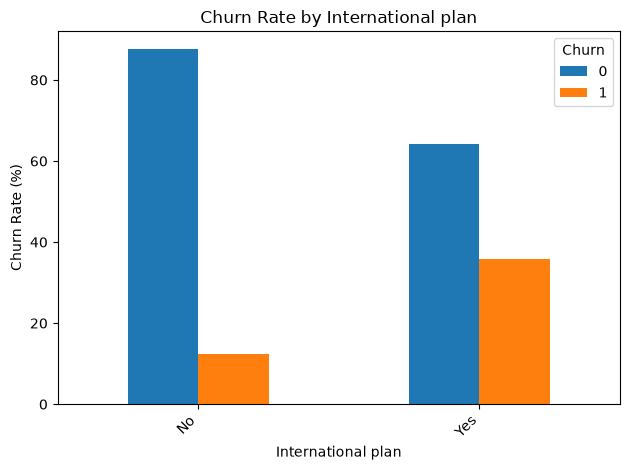

<Figure size 800x400 with 0 Axes>

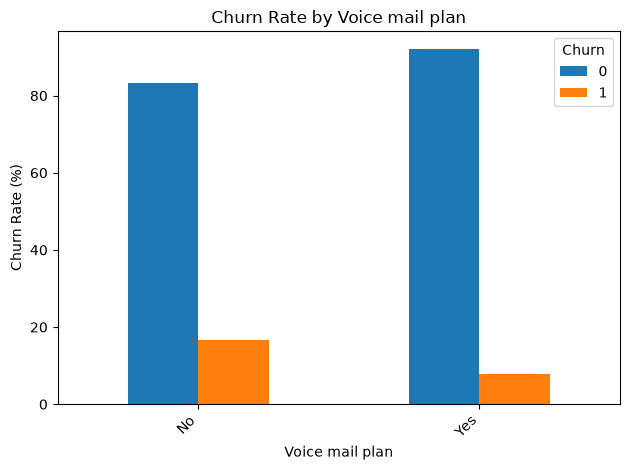

<Figure size 800x400 with 0 Axes>

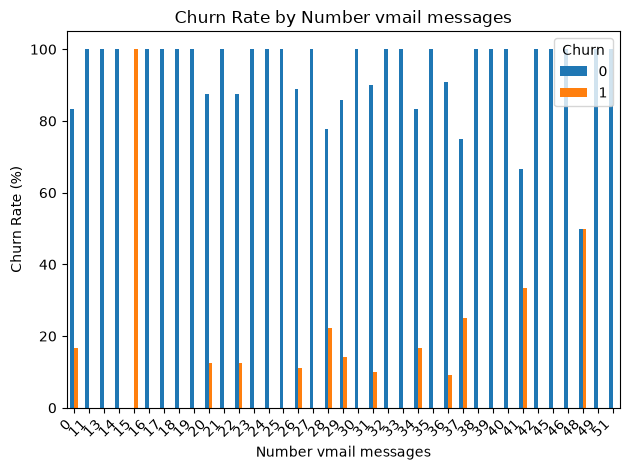

<Figure size 800x400 with 0 Axes>

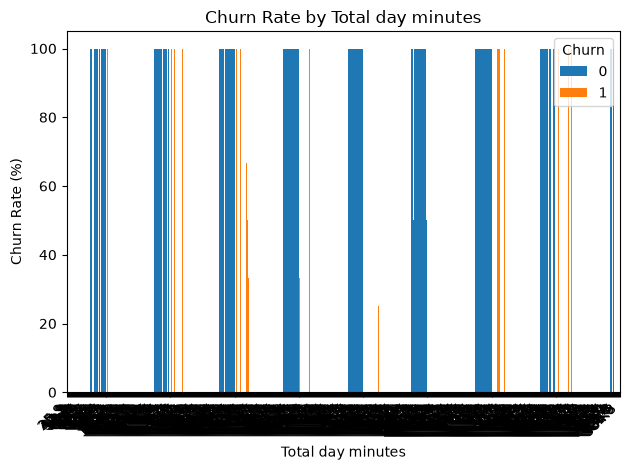

<Figure size 800x400 with 0 Axes>

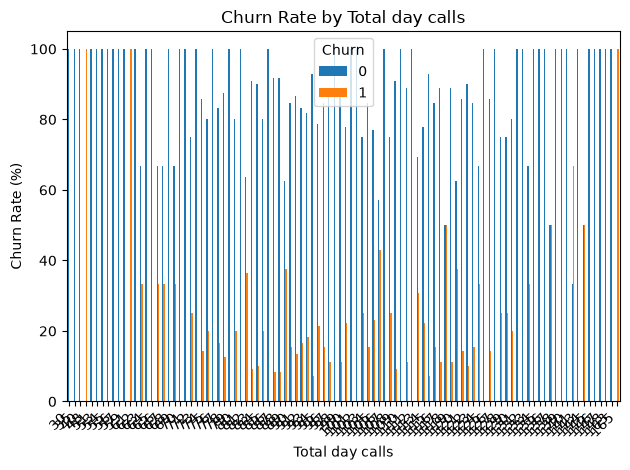

<Figure size 800x400 with 0 Axes>

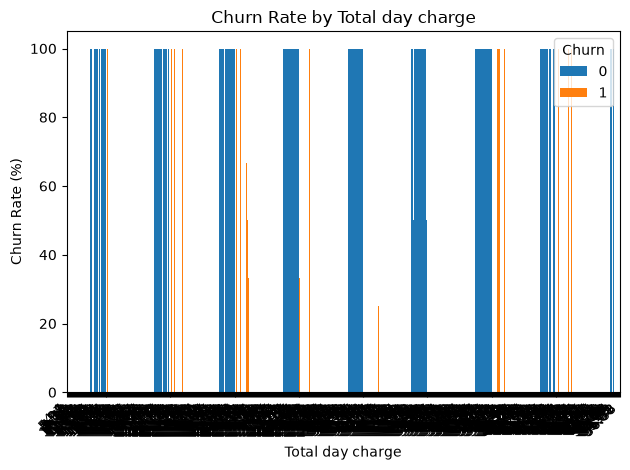

<Figure size 800x400 with 0 Axes>

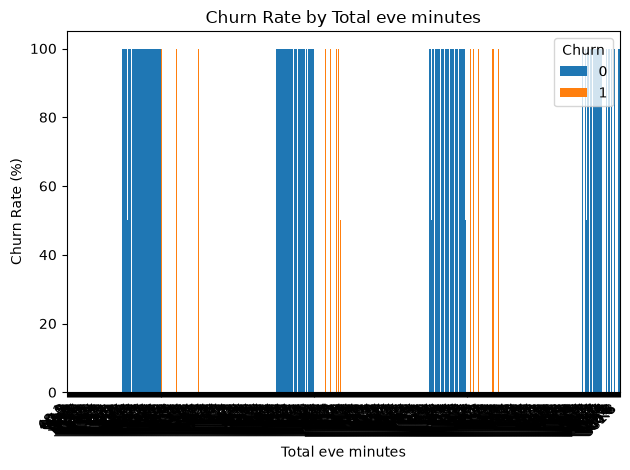

<Figure size 800x400 with 0 Axes>

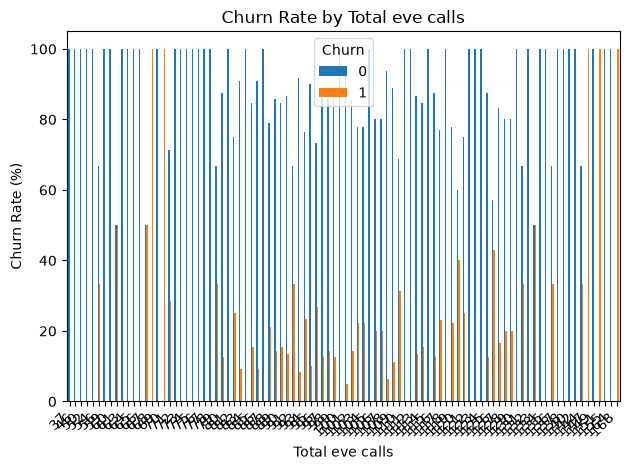

<Figure size 800x400 with 0 Axes>

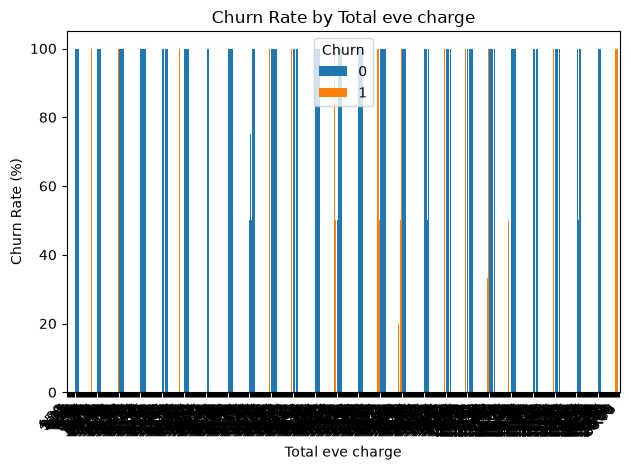

<Figure size 800x400 with 0 Axes>

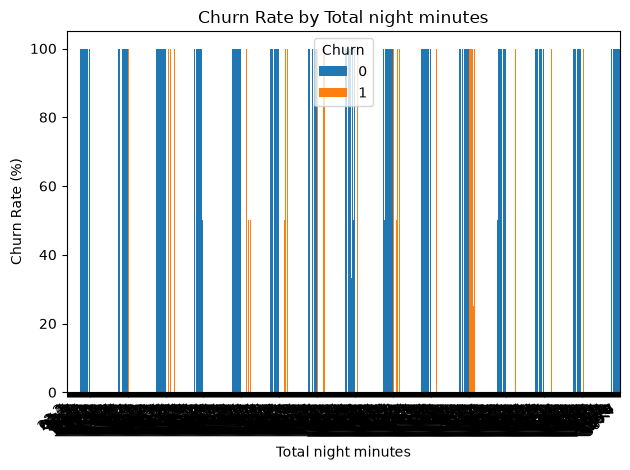

<Figure size 800x400 with 0 Axes>

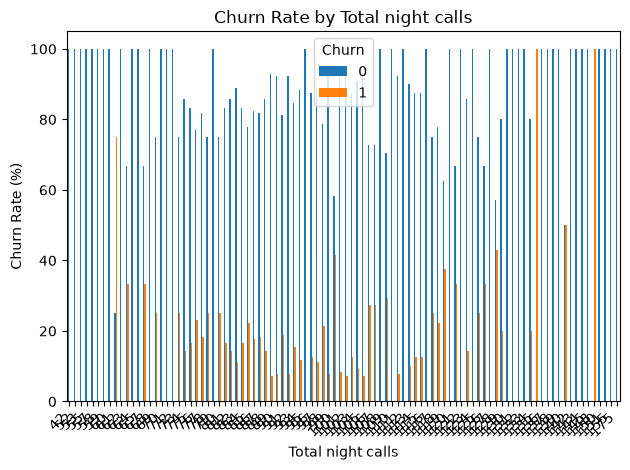

<Figure size 800x400 with 0 Axes>

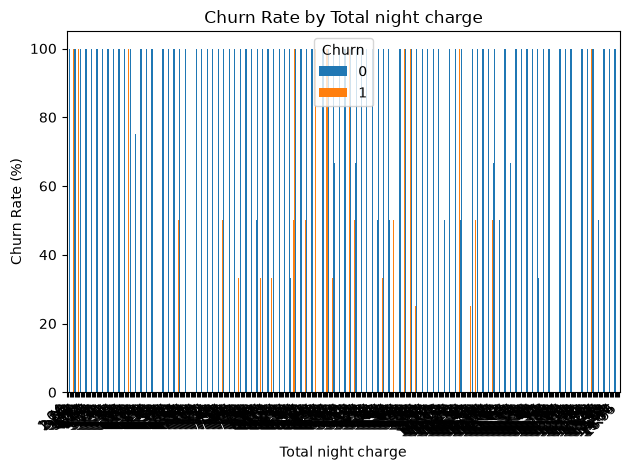

<Figure size 800x400 with 0 Axes>

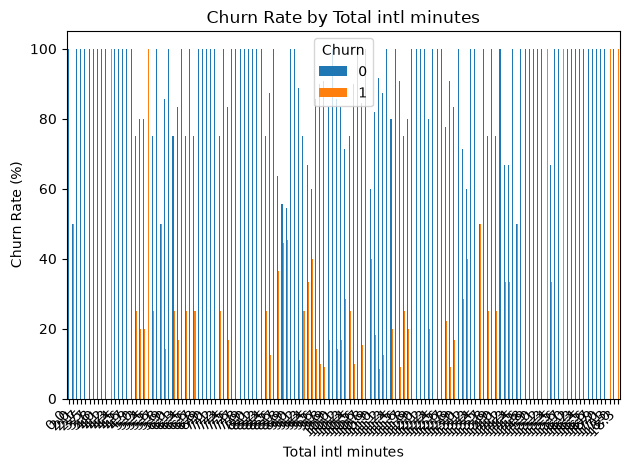

<Figure size 800x400 with 0 Axes>

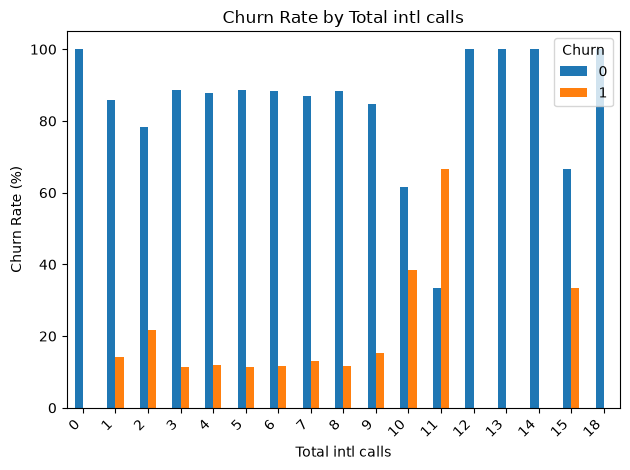

<Figure size 800x400 with 0 Axes>

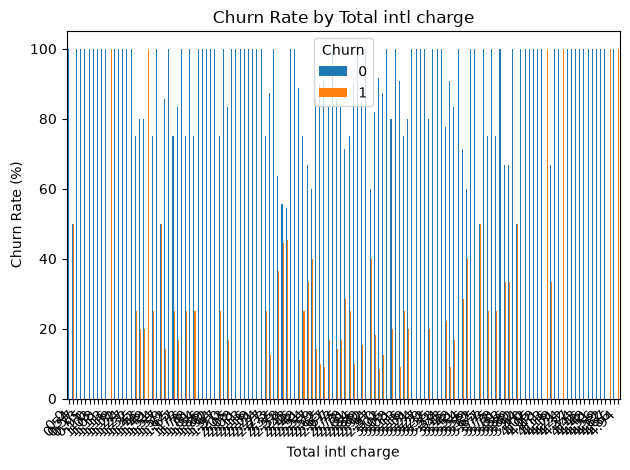

<Figure size 800x400 with 0 Axes>

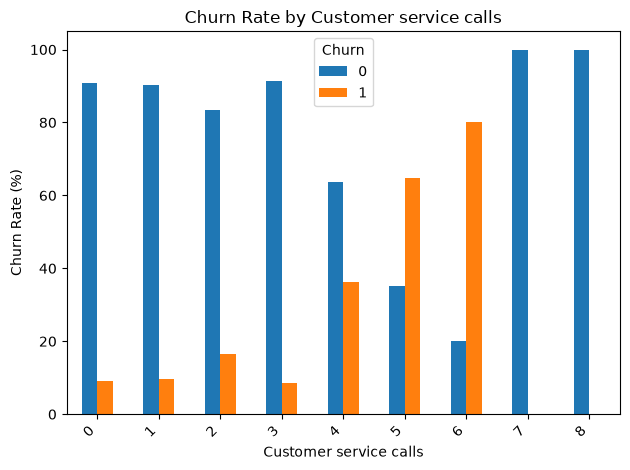

<Figure size 800x400 with 0 Axes>

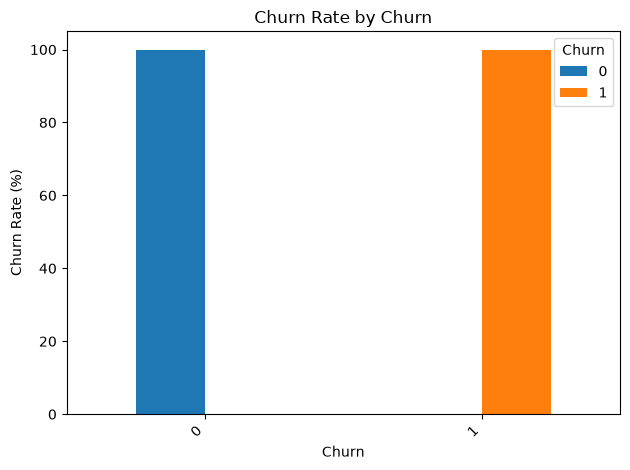

In [37]:
# Churn rate by importance of features

for col in candidate_cols:
    if col in df.columns and "Churn" in df.columns:
        churn_rate = pd.crosstab(df[col], df["Churn"], normalize="index").mul(100)
        # print(churn_rate)
        if "Yes" in churn_rate.columns:
            churn_rate = churn_rate[["Yes"]].sort_values("Yes", ascending=False)
            display(churn_rate.style.format("{:.2f}%").set_caption(f"Churn Rate by {col}"))
            
    plt.figure(figsize=(8, 4))
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.show()

                        Account length  Area code  Number vmail messages  \
Account length                1.000000  -0.026327              -0.011993   
Area code                    -0.026327   1.000000              -0.006907   
Number vmail messages        -0.011993  -0.006907               1.000000   
Total day minutes             0.017833   0.051507              -0.069172   
Total day calls               0.035703  -0.008972              -0.009952   
Total day charge              0.017839   0.051492              -0.069187   
Total eve minutes             0.027043   0.017160               0.040865   
Total eve calls               0.021237   0.017783              -0.051951   
Total eve charge              0.027051   0.017182               0.040876   
Total night minutes          -0.007527  -0.016832               0.039751   
Total night calls             0.027228   0.036421               0.003367   
Total night charge           -0.007528  -0.016818               0.039680   
Total intl m

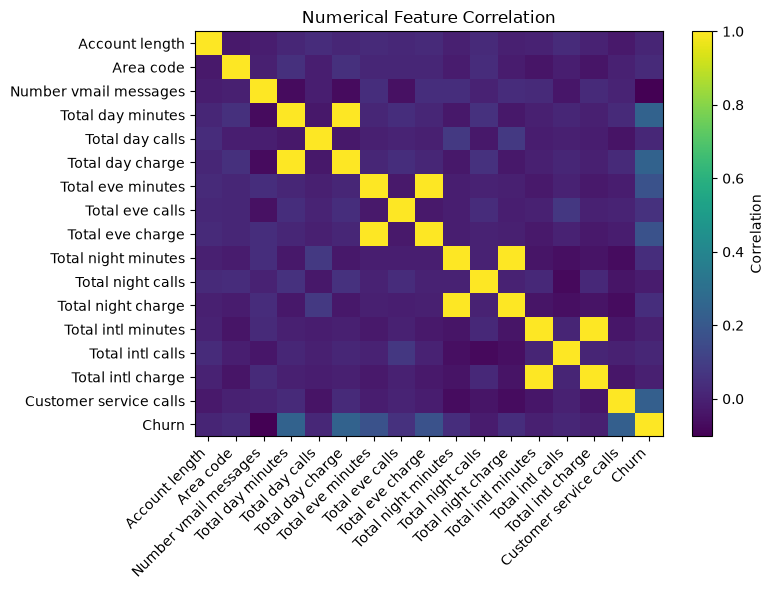

In [38]:
# Correlation among numerical variables
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    print(corr)
   
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Numerical Feature Correlation")
    plt.tight_layout()
    plt.show()

In [39]:
df["Churn"] = df["Churn"].astype(int)

print(df["Churn"].dtype)
print(df["Churn"].unique())
print(df["Churn"].value_counts())

int64
[0 1]
Churn
0    572
1     95
Name: count, dtype: int64


In [40]:

# Remove rows where target is missing
df = df.dropna(subset=['Churn']).copy()

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

In [ ]:
X 

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1


In [42]:
y

0      0
1      1
2      1
3      0
4      0
      ..
662    0
663    0
664    0
665    0
666    0
Name: Churn, Length: 667, dtype: int64

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [44]:
print(f'X_train:{X_train.shape}')
print(f'X_test :{X_test.shape}')
print(f'y_train:{y_train.shape}')
print(f'y_test :{y_test.shape}')

X_train:(533, 19)
X_test :(134, 19)
y_train:(533,)
y_test :(134,)


In [45]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

In [46]:
numeric_features

['Account length',
 'Area code',
 'Number vmail messages',
 'Total day minutes',
 'Total day calls',
 'Total day charge',
 'Total eve minutes',
 'Total eve calls',
 'Total eve charge',
 'Total night minutes',
 'Total night calls',
 'Total night charge',
 'Total intl minutes',
 'Total intl calls',
 'Total intl charge',
 'Customer service calls']

In [47]:
categorical_features

['State', 'International plan', 'Voice mail plan']

In [48]:
# Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [49]:

# sparse_output=False works with current scikit-learn versions.
# If using an older version, replace it with sparse=False.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [50]:

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [51]:
print(f'Training shape:{X_train.shape}')
print(f'Testing shape :{X_test.shape}')
print(f'Numerical features:{numeric_features}')
print(f'Categorical features:{categorical_features}')

Training shape:(533, 19)
Testing shape :(134, 19)
Numerical features:['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
Categorical features:['State', 'International plan', 'Voice mail plan']


In [52]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

In [53]:
models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                        random_state=42)}

In [54]:
results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    print(f'pipe:{pipe}')
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    print(f'y_pred:{y_pred}')

    print(pd.DataFrame(y_pred).value_counts())

    if hasattr(pipe, "predict_proba"):
        # print(f'probability of yes_no is {y_prob}')
        y_prob = pipe.predict_proba(X_test)[:, 1]
        print(f'y_prob:{y_prob}')
    else:
        y_prob = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False)
results_df



pipe:Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Account length',
                                                   'Area code',
                                                   'Number vmail messages',
                                                   'Total day minutes',
                                                   'Total day calls',
                                                   'Total day charge',
                                                   'Total eve minutes',
                                                   'Total eve call

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.925373,0.846154,0.578947,0.687500,0.893593
1,Decision Tree,0.880597,0.571429,0.631579,0.600000,0.776659
0,Logistic Regression,0.761194,0.303030,0.526316,0.384615,0.774371


In [55]:
print(fitted_models)


{'Logistic Regression': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Account length',
                                                   'Area code',
                                                   'Number vmail messages',
                                                   'Total day minutes',
                                                   'Total day calls',
                                                   'Total day charge',
                                                   'Total eve minutes',
                                               

In [56]:

# Select the best model using ROC AUC.
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]

print("Best model:", best_name)



print(best_model)

Best model: Random Forest
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Account length',
                                                   'Area code',
                                                   'Number vmail messages',
                                                   'Total day minutes',
                                                   'Total day calls',
                                                   'Total day charge',
                                                   'Total eve minutes',
                                             

In [57]:
# Save COMPLETE pipeline, includeing preprocessing
joblib.dump(best_model, MODEL_FILE)
print(f"Model saved to: {MODEL_FILE}")

Model saved to: churn_model.pkl


In [58]:
# Test that we saved pipeline can be loaded again
loaded_model = joblib.load(MODEL_FILE)

In [59]:
loaded_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['State','Account length','Area code',...,'Total intl calls', 'Total intl charge','Customer service calls']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi